# Book Recommendation System
Recommendation systems connect people with items they are likely to enjoy by learning from their preferences and behavior. For digital products, effective recommenders lift engagement and revenue by keeping users active and satisfied. In this project, we build a book recommendation system with Machine Learning in Python and walk through the end-to-end process.

<div align="center">
<img src="https://static.vecteezy.com/system/resources/thumbnails/044/280/984/small_2x/stack-of-books-on-a-brown-background-concept-for-world-book-day-photo.jpg" />
</div>

## Why recommendations matter for books
Platforms for reading and buying books—such as Kindle and Goodreads—compete on discovery. A strong recommendation engine surfaces relevant titles for each reader, which improves satisfaction and retention. Our aim is to suggest books aligned with a user's tastes, inferred from signals like ratings, metadata, and interactions.

The core objective of a book recommender is to predict a reader’s interests and present meaningful suggestions. Such systems can leverage multiple sources of information, including content features, popularity, and user feedback. In the next section, we’ll implement a practical machine learning pipeline for book recommendations in Python.

## Book Recommendation System with Machine Learning
Below, we implement a hands-on book recommender in Python. We’ll import the required libraries, prepare the dataset, and iterate from simple baselines to stronger approaches. The dataset we’ll use is available on Kaggle: [Goodreads-books](https://www.kaggle.com/jealousleopard/goodreadsbooks).

## 1. Importing Libraries
First, let’s import the necessary libraries.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

### Configuration
Let's configure the necessary settings.
- Ignore warnings for cleaner output.
- Set default figure size to 12x8 inches for plots.
- Use seaborn's 'darkgrid' style for improved plot aesthetics.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
Next, we will load the dataset into a pandas DataFrame and take a quick look at its structure.

In [3]:
df = pd.read_csv('books.csv', index_col=0, on_bad_lines='skip')

In [4]:
df.head()

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,,
1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [5]:
df.shape

(11123, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11123 entries, 1 to 45641
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               11123 non-null  object 
 1   authors             11123 non-null  object 
 2   average_rating      11123 non-null  float64
 3   isbn                11123 non-null  object 
 4   isbn13              11123 non-null  int64  
 5   language_code       11123 non-null  object 
 6     num_pages         11123 non-null  int64  
 7   ratings_count       11123 non-null  int64  
 8   text_reviews_count  11123 non-null  int64  
 9   publication_date    11123 non-null  object 
 10  publisher           11123 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 1.0+ MB


In [7]:
df.isnull().sum()

title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

## 3. Exploratory Data Analysis
Let's explore the data to understand it better.

In [8]:
df.describe()

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


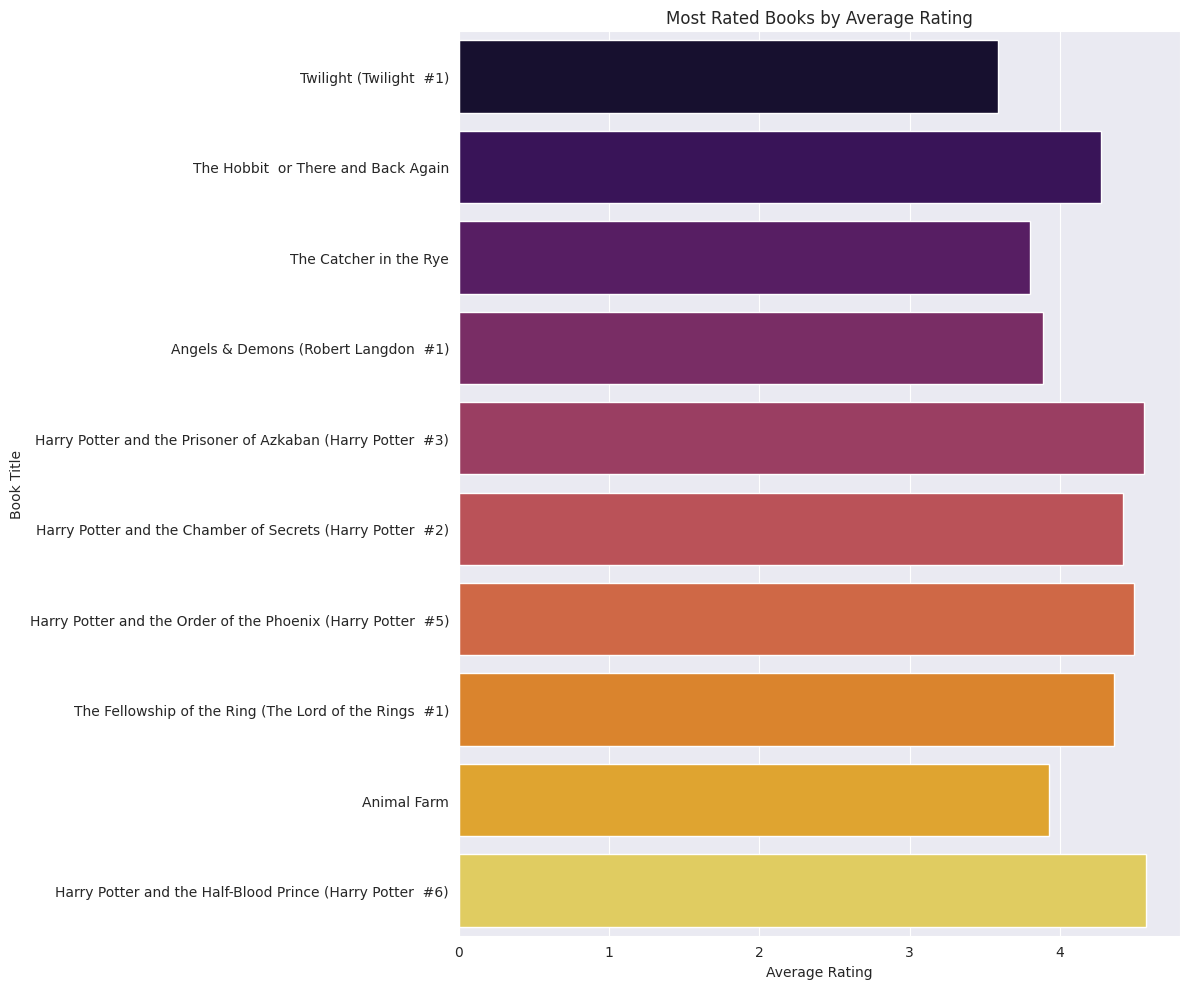

In [9]:
top_10 = df.sort_values(by='ratings_count', ascending=False).head(10)

plt.figure(figsize=(12, 10))
sns.barplot(x='average_rating', y='title', data=top_10, palette='inferno')
plt.title('Most Rated Books by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Book Title')
plt.tight_layout()

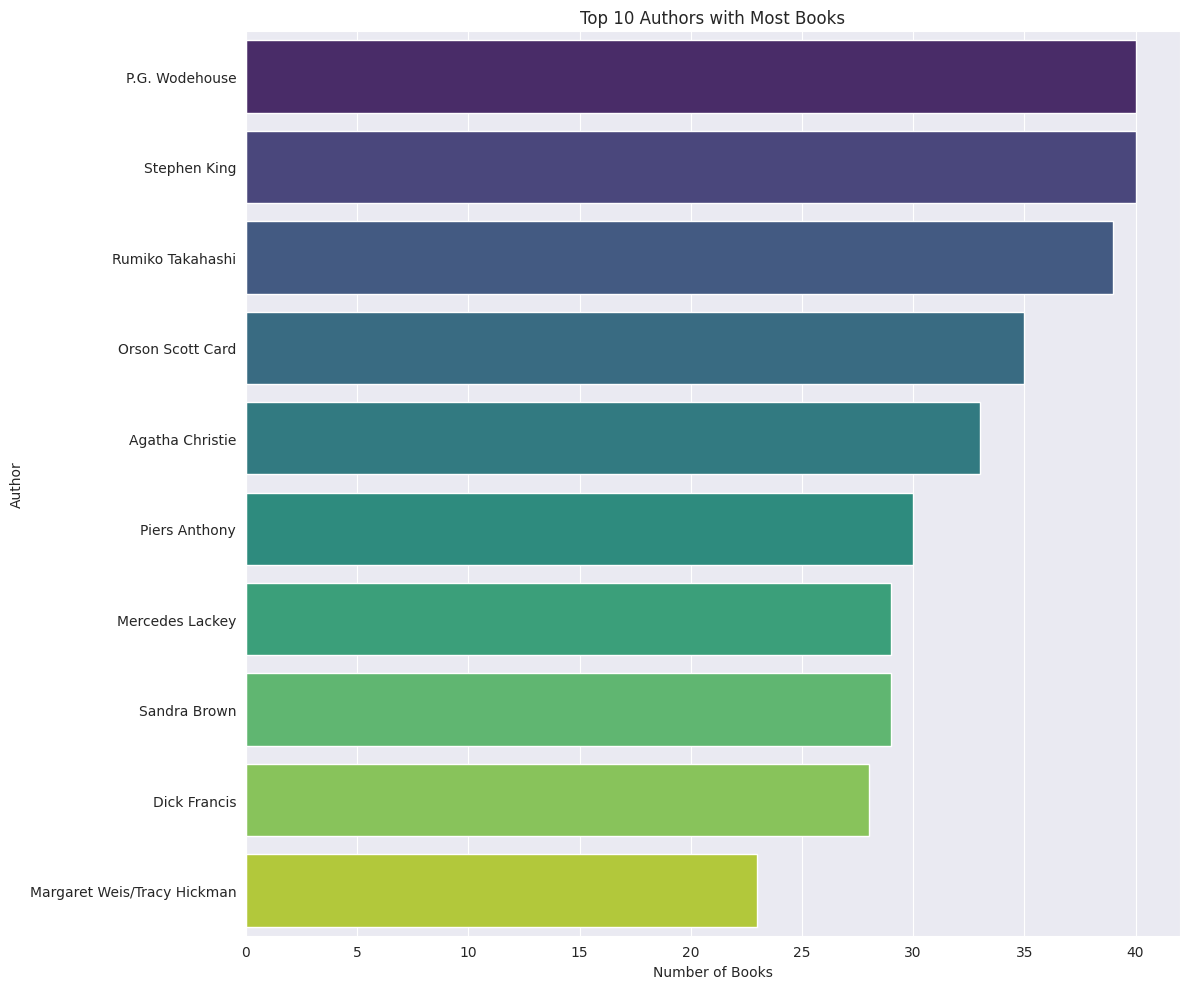

In [10]:
most_authors = df.groupby('authors')['title'].count().reset_index().sort_values('title', ascending=False).head(10).set_index('authors')

plt.figure(figsize=(12, 10))
sns.barplot(x='title', y='authors', data=most_authors, palette='viridis')
plt.title('Top 10 Authors with Most Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.tight_layout()

Text(0, 0.5, 'Book Title')

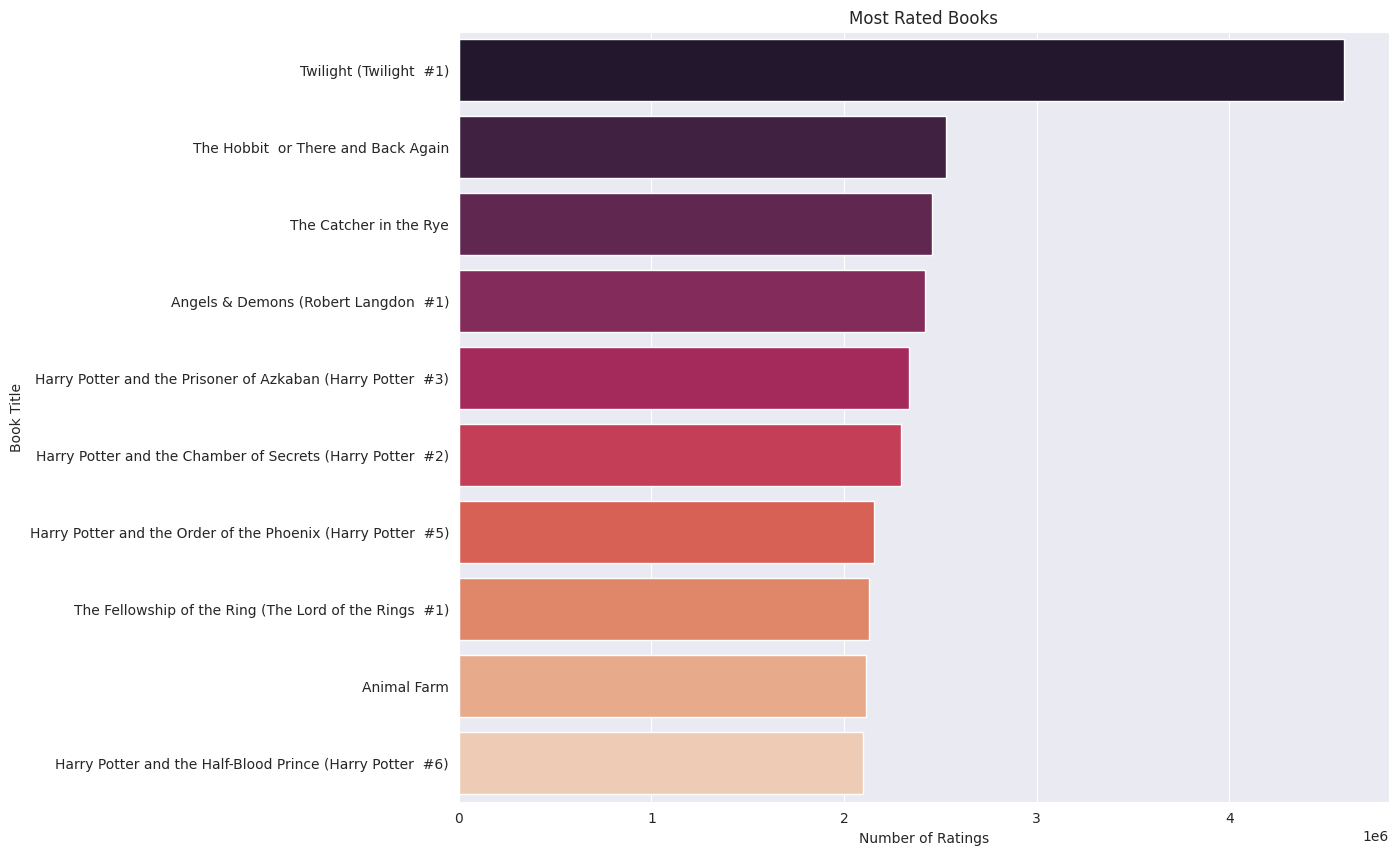

In [11]:
most_rated = df.sort_values(by='ratings_count', ascending=False).head(10).set_index('title')

plt.figure(figsize=(12, 10))
sns.barplot(x='ratings_count', y='title', data=most_rated, palette='rocket')
plt.title('Most Rated Books')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')

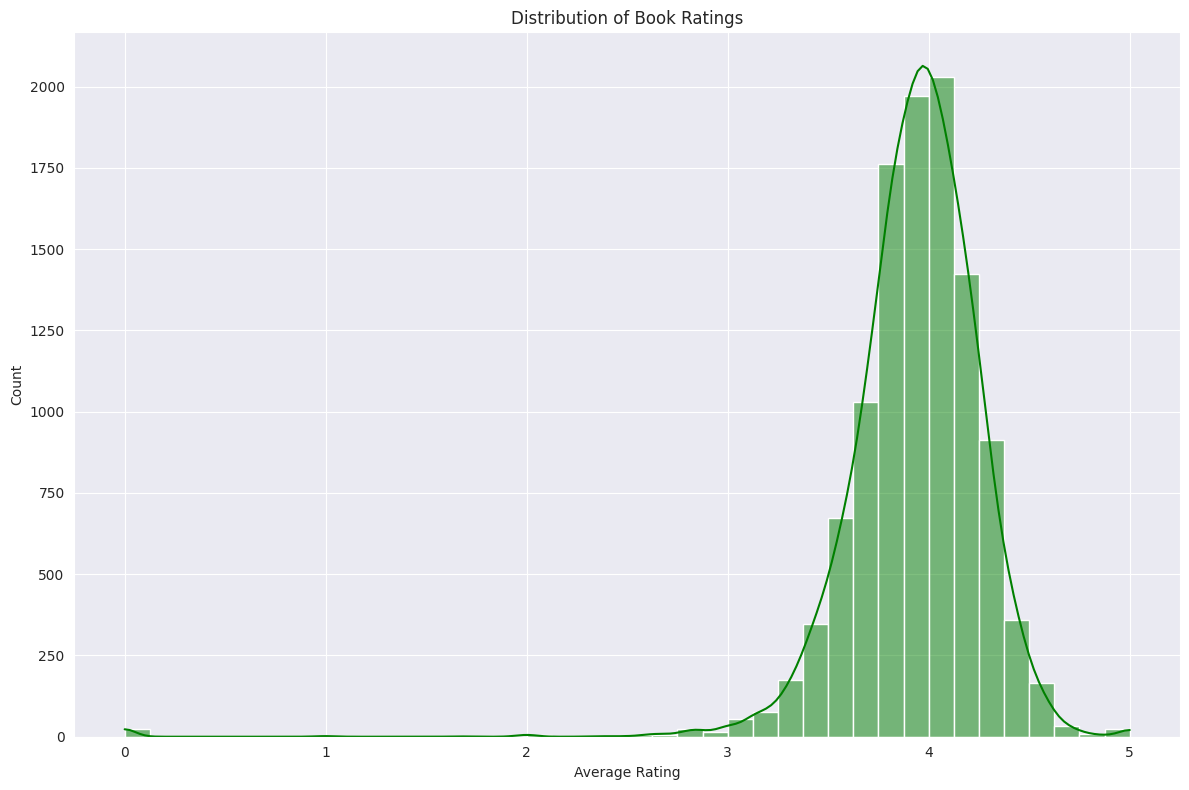

In [12]:
sns.histplot(df['average_rating'], bins=40, kde=True, color='g')
plt.title('Distribution of Book Ratings')
plt.xlabel('Average Rating')
plt.tight_layout()

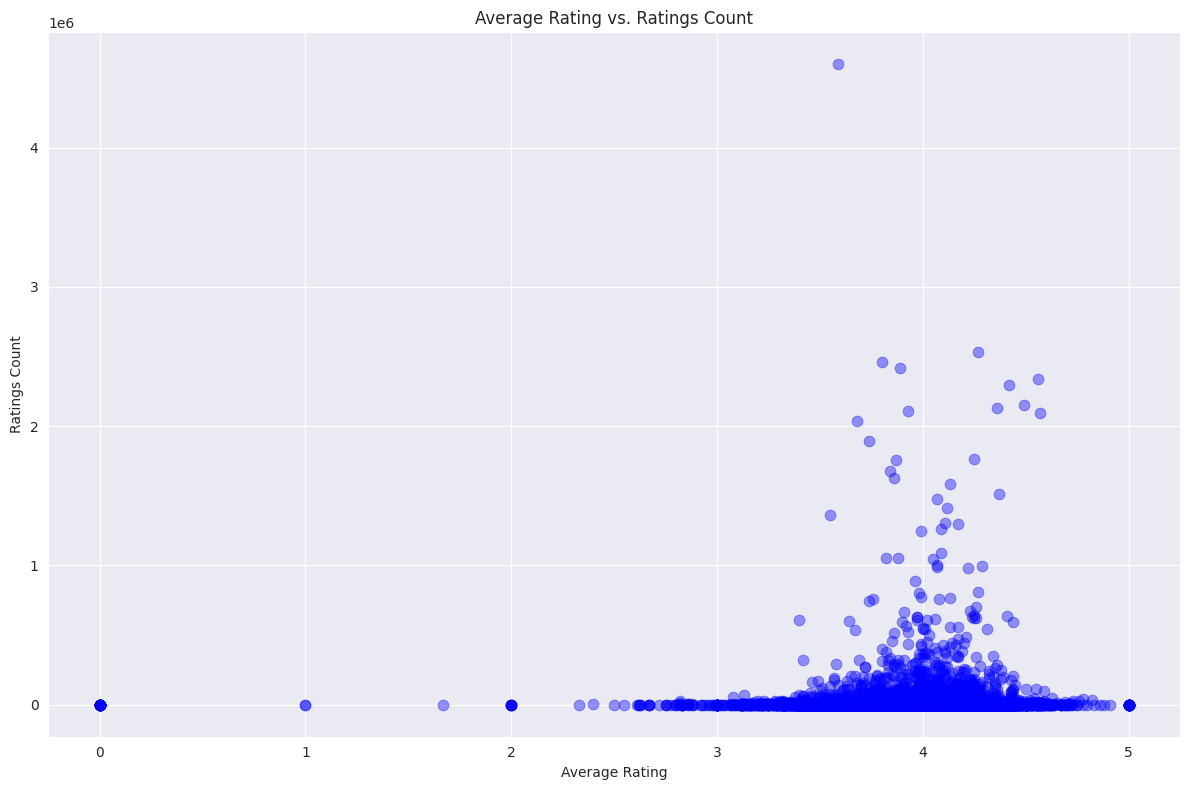

In [13]:
sns.scatterplot(
    df,
    x='average_rating',
    y='ratings_count',
    color='blue',
    alpha=0.4,
    s=60,
    edgecolor=None
)
plt.title('Average Rating vs. Ratings Count')
plt.xlabel('Average Rating')
plt.ylabel('Ratings Count')
plt.tight_layout()

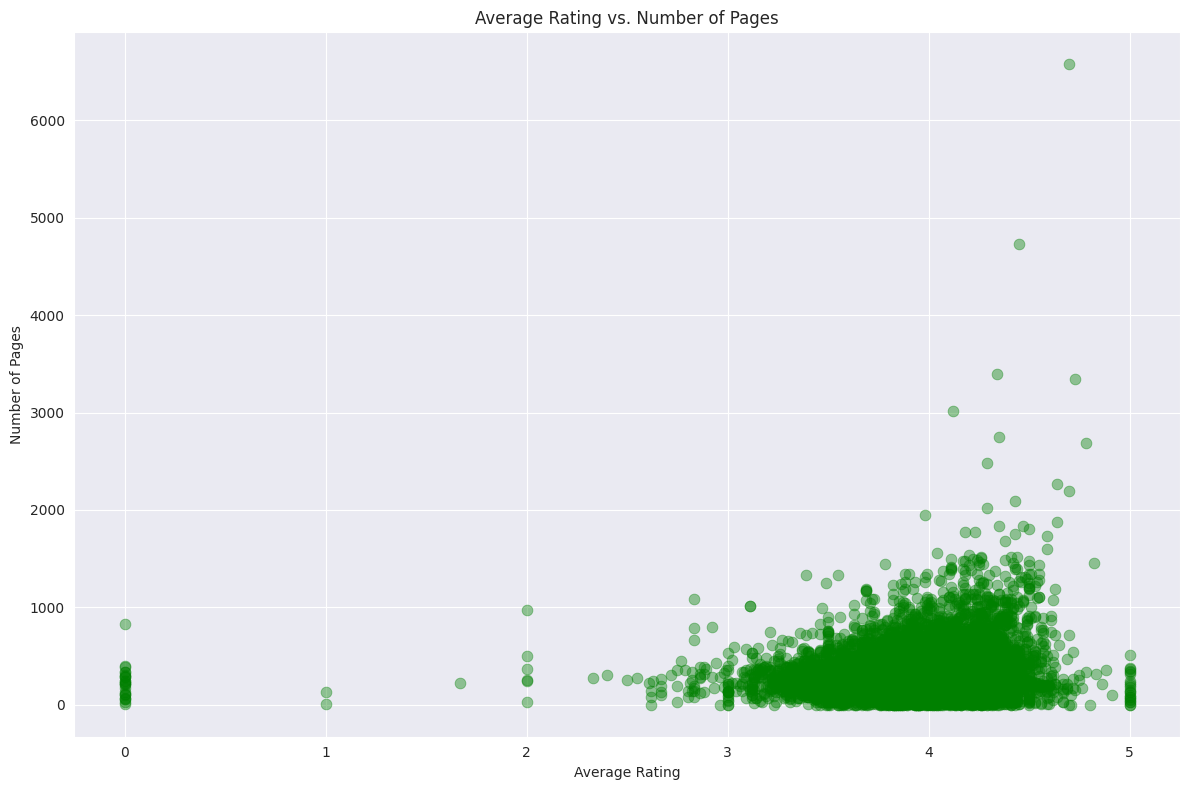

In [14]:
sns.scatterplot(
    df,
    x='average_rating',
    y='  num_pages',
    color='green',
    alpha=0.4,
    s=60,
    edgecolor=None
)
plt.title('Average Rating vs. Number of Pages')
plt.xlabel('Average Rating')
plt.ylabel('Number of Pages')
plt.tight_layout()

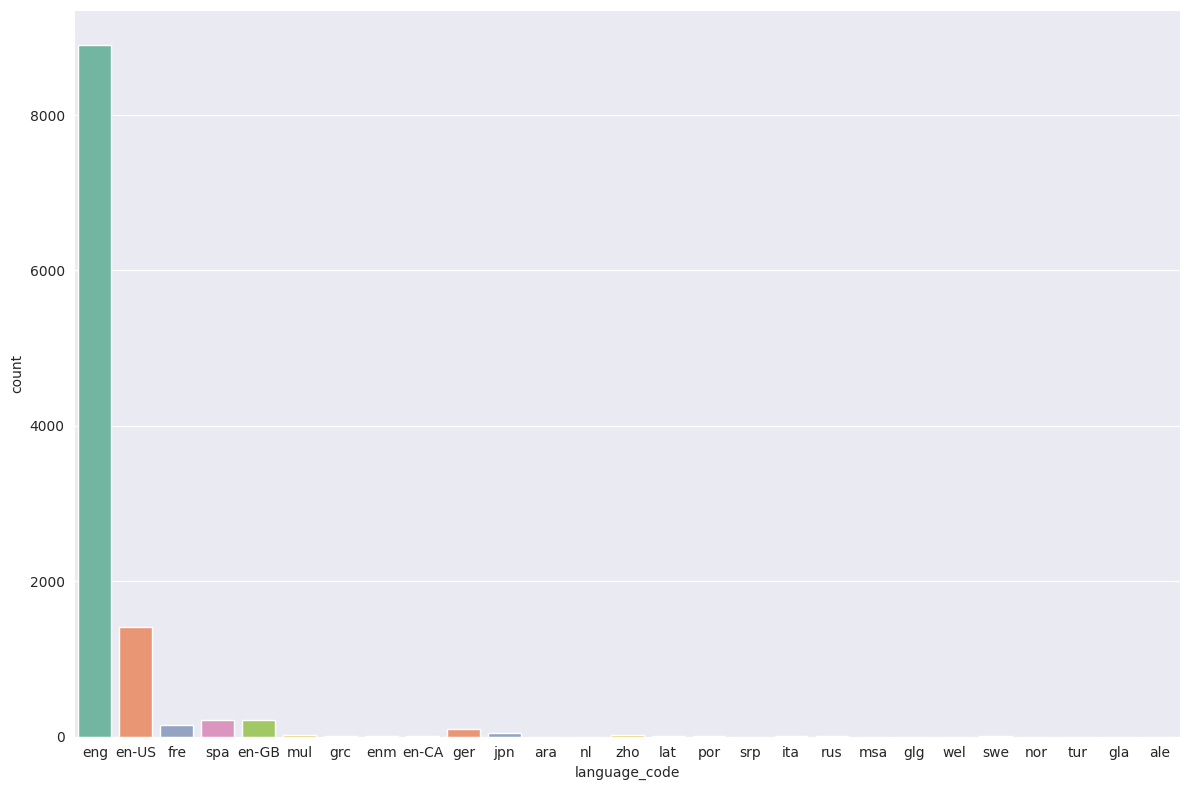

In [15]:
sns.countplot(x=df.language_code, palette='Set2')
plt.tight_layout()

## 4. Data Preprocessing
Let's preprocess the data to make it ready for the recommendation.

In [27]:
# books grouped and aggregated by ratings_count and average_rating
bg = df.groupby('title').agg({
    'ratings_count': ['size', 'sum', 'mean'],
    'average_rating': 'mean'
})
bg

ratings_count         \
                                                            size    sum   
title                                                                     
  said the shotgun to the head.                                1   2762   
$30 Film School: How to Write  Direct  Produce ...             1     30   
'Salem's Lot                                                   8  85852   
1 000 Places to See Before You Die                             1  36303   
10 lb Penalty                                                  1   3490   
...                                                          ...    ...   
鋼之鍊金術師 6                                                       1      5   
鋼之鍊金術師 7                                                       1      5   
鋼之鍊金術師 9                                                       1      4   
魔戒二部曲：雙城奇謀                                                     1     24   
魔戒首部曲：魔戒現身                                                     1     26   

                                                            average_rating  
                                                       mean           mean  
title                                                                       
  said the shotgun to the head.                      2762.0        4.22000  
$30 Film School: How to Write  Direct  Produce ...     30.0        3.49000  
'Salem's Lot                                        10731.5        4.04875  
1 000 Places to See Before You Die                  36303.0        3.85000  
10 lb Penalty                                        3490.0        3.90000  
...                                                     ...            ...  
鋼之鍊金術師 6                                                5.0        4.58000  
鋼之鍊金術師 7                                                5.0        4.57000  
鋼之鍊金術師 9                                                4.0        4.57000  
魔戒二部曲：雙城奇謀                                             24.0        4.44000  
魔戒首部曲：魔戒現身                                             26.0        4.36000  

[10348 rows x 4 columns]

In [33]:
# Total sum of ratings.
ts = bg['ratings_count']['sum'].sum()
ts

np.int64(199578299)

In [52]:
bg['percentage'] = bg['ratings_count']['sum'].div(ts) * 100

In [53]:
bg.head()

ratings_count         \
                                                            size    sum   
title                                                                     
  said the shotgun to the head.                                1   2762   
$30 Film School: How to Write  Direct  Produce ...             1     30   
'Salem's Lot                                                   8  85852   
1 000 Places to See Before You Die                             1  36303   
10 lb Penalty                                                  1   3490   

                                                            average_rating  \
                                                       mean           mean   
title                                                                        
  said the shotgun to the head.                      2762.0        4.22000   
$30 Film School: How to Write  Direct  Produce ...     30.0        3.49000   
'Salem's Lot                                        10731.5        4.04875   
1 000 Places to See Before You Die                  36303.0        3.85000   
10 lb Penalty                                        3490.0        3.90000   

                                                   percentage  
                                                               
title                                                          
  said the shotgun to the head.                      0.001384  
$30 Film School: How to Write  Direct  Produce ...   0.000015  
'Salem's Lot                                         0.043017  
1 000 Places to See Before You Die                   0.018190  
10 lb Penalty                                        0.001749

In [54]:
bg['rank'] = bg['percentage'].rank(ascending=False)

In [ ]:
bg = bg.sort_values(by='rank', ascending=True)
bg

ratings_count           \
                                                            size      sum   
title                                                                       
Twilight (Twilight  #1)                                        1  4597666   
The Hobbit  or There and Back Again                            1  2530894   
The Catcher in the Rye                                         1  2457092   
Angels & Demons (Robert Langdon  #1)                           3  2425666   
Harry Potter and the Prisoner of Azkaban (Harry...             2  2342726   
...                                                          ...      ...   
The Goon Show: Moriarty Where Are You?                         1        0   
American Government: Continuity and Change  Tex...             1        0   
American Government: Continuity and Change  Alt...             1        0   
Sclerotherapy and vein treatment                               1        0   
Worlds of Wonder                                               1        0   

                                                                  \
                                                            mean   
title                                                              
Twilight (Twilight  #1)                             4.597666e+06   
The Hobbit  or There and Back Again                 2.530894e+06   
The Catcher in the Rye                              2.457092e+06   
Angels & Demons (Robert Langdon  #1)                8.085553e+05   
Harry Potter and the Prisoner of Azkaban (Harry...  1.171363e+06   
...                                                          ...   
The Goon Show: Moriarty Where Are You?              0.000000e+00   
American Government: Continuity and Change  Tex...  0.000000e+00   
American Government: Continuity and Change  Alt...  0.000000e+00   
Sclerotherapy and vein treatment                    0.000000e+00   
Worlds of Wonder                                    0.000000e+00   

                                                   average_rating percentage  \
                                                             mean              
title                                                                          
Twilight (Twilight  #1)                                      3.59   2.303690   
The Hobbit  or There and Back Again                          4.27   1.268121   
The Catcher in the Rye                                       3.80   1.231142   
Angels & Demons (Robert Langdon  #1)                         3.89   1.215396   
Harry Potter and the Prisoner of Azkaban (Harry...           4.56   1.173838   
...                                                           ...        ...   
The Goon Show: Moriarty Where Are You?                       4.43   0.000000   
American Government: Continuity and Change  Tex...           2.83   0.000000   
American Government: Continuity and Change  Alt...           2.83   0.000000   
Sclerotherapy and vein treatment                             0.00   0.000000   
Worlds of Wonder                                             4.13   0.000000   

                                                       rank  
                                                             
title                                                        
Twilight (Twilight  #1)                                 1.0  
The Hobbit  or There and Back Again                     2.0  
The Catcher in the Rye                                  3.0  
Angels & Demons (Robert Langdon  #1)                    4.0  
Harry Potter and the Prisoner of Azkaban (Harry...      5.0  
...                                                     ...  
The Goon Show: Moriarty Where Are You?              10310.5  
American Government: Continuity and Change  Tex...  10310.5  
American Government: Continuity and Change  Alt...  10310.5  
Sclerotherapy and vein treatment                    10310.5  
Worlds of Wonder                                    10310.5  

[10348 rows x 6 columns]

In [ ]:
# Most popular 10 books.
bg.head(10)

## 5. Recommendation
Let's recommend the most popular books to the user.

In [58]:
p10_books = bg.head(10)

In [69]:
p10_books.sort_values(by=('average_rating', 'mean'), ascending=False)[[('average_rating', 'mean'), ('ratings_count', 'sum')]]

,average_rating,ratings_count
,mean,sum
title,,
100 Years of Lynchings,4.61000,88
100 Love Sonnets,4.39000,12613
1000 Rings: Inspiring Adornments for the Hand,4.23000,82
said the shotgun to the head.,4.22000,2762
'Salem's Lot,4.04875,85852
100 Great Fantasy Short Short Stories,3.91000,204
10 lb Penalty,3.90000,3490
1 000 Places to See Before You Die,3.85000,36303


## 6. Conclusion

### Project Summary
This book recommendation system successfully demonstrates fundamental recommendation concepts using a Goodreads dataset of 11,123 books. The project implements a popularity-based approach that combines rating quality and quantity to identify the most popular and highly-rated books.

### Key Insights
- **Data Quality:** Clean dataset with comprehensive metadata including ratings, page counts, and author information
- **Rating Distribution:** Most books fall in the 3.5-4.5 rating range with strong correlation between rating count and popularity
- **Recommendation Logic:** Effective popularity-based ranking using percentage of total ratings
- **Technical Implementation:** Solid data preprocessing pipeline with comprehensive EDA visualizations

### Future Improvements

**1. Advanced Algorithms:**
- Implement collaborative filtering for personalized recommendations
- Add content-based filtering using book metadata and descriptions
- Combine multiple approaches with hybrid recommendation systems

**2. Enhanced Data Processing:**
- Incorporate NLP techniques for book descriptions and reviews
- Add genre classification and temporal analysis
- Include user behavior tracking and interaction data

**3. Machine Learning Integration:**
- Implement deep learning models for complex pattern recognition
- Use matrix factorization techniques (SVD, neural collaborative filtering)
- Create ensemble methods combining multiple models

**4. System Architecture:**
- Build scalable APIs for real-time recommendations
- Implement proper evaluation metrics (precision, recall, NDCG)
- Add A/B testing framework for continuous improvement

### Business Applications
This system can enhance book discovery for e-commerce platforms, library systems, educational platforms, and publishing industry market analysis.

### Final Thoughts
While this project provides a solid foundation in recommendation systems, transforming it into a production-ready system requires implementing personalization, advanced ML algorithms, and proper evaluation frameworks. The combination of data analysis skills and recommendation system understanding makes this an excellent starting point for building sophisticated recommendation engines.